In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

from typing import Any
from jaxtyping import PyTree

import datasets as hf_datasets
from datasets import load_dataset

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import flax.linen as nn

from jaxili.utils import create_data_loader
from jaxili.inference import NPE, NLE
from jaxili.train import TrainerModule
from jaxili.compressor import MLPCompressor
from jaxili.compressor import Compressor

from getdist import plots, MCSamples
%matplotlib inline

print("Jax device:", jax.devices())

Jax device: [CudaDevice(id=0)]


In [2]:
path_dataset = "/lustre/fswork/projects/rech/prk/commun/GowerStreetSims/UNIONS_sims_pseudo_cell.parquet"

dataset = load_dataset("parquet", data_files=path_dataset)

In [3]:
dataset = dataset.with_format('numpy')

In [4]:
#Split in training set for compression and inference
dataset = dataset["train"].train_test_split(test_size=0.5)

In [5]:
def dataset_preprocessing(example):
    example['theta'] = np.array([example["Omega_m"], example["sigma_8"], example["w"]])
    pseudo_cell = example["pseudo_cell"].reshape((4, -1))
    example['x'] = np.concatenate([pseudo_cell[0], pseudo_cell[3]]).flatten()
    return example

In [6]:
dataset = dataset.map(dataset_preprocessing)

Map:   0%|          | 0/19750 [00:00<?, ? examples/s]

Map:   0%|          | 0/19750 [00:00<?, ? examples/s]

In [7]:
dataset["compression"] = dataset["train"]
dataset.pop("train")
dataset["inference"] = dataset["test"]
dataset.pop("test")

Dataset({
    features: ['id', 'h', 'Omega_m', 'Omega_b', 'sigma_8', 'n_s', 'w', 'm_nu', 'A_s', 'ell_eff', 'pseudo_cell', 'pseudo_cell_sys', 'theta', 'x'],
    num_rows: 19750
})

In [8]:
dataset

DatasetDict({
    compression: Dataset({
        features: ['id', 'h', 'Omega_m', 'Omega_b', 'sigma_8', 'n_s', 'w', 'm_nu', 'A_s', 'ell_eff', 'pseudo_cell', 'pseudo_cell_sys', 'theta', 'x'],
        num_rows: 19750
    })
    inference: Dataset({
        features: ['id', 'h', 'Omega_m', 'Omega_b', 'sigma_8', 'n_s', 'w', 'm_nu', 'A_s', 'ell_eff', 'pseudo_cell', 'pseudo_cell_sys', 'theta', 'x'],
        num_rows: 19750
    })
})

# Training the compressor

In [9]:
compression_dataset = dataset["compression"].train_test_split(test_size=0.3)
temp_dataset = compression_dataset["test"].train_test_split(test_size=0.5)
compression_dataset["val"] = temp_dataset["train"]
compression_dataset["test"] = temp_dataset["test"]
del temp_dataset

In [10]:
compression_dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'h', 'Omega_m', 'Omega_b', 'sigma_8', 'n_s', 'w', 'm_nu', 'A_s', 'ell_eff', 'pseudo_cell', 'pseudo_cell_sys', 'theta', 'x'],
        num_rows: 13825
    })
    test: Dataset({
        features: ['id', 'h', 'Omega_m', 'Omega_b', 'sigma_8', 'n_s', 'w', 'm_nu', 'A_s', 'ell_eff', 'pseudo_cell', 'pseudo_cell_sys', 'theta', 'x'],
        num_rows: 2963
    })
    val: Dataset({
        features: ['id', 'h', 'Omega_m', 'Omega_b', 'sigma_8', 'n_s', 'w', 'm_nu', 'A_s', 'ell_eff', 'pseudo_cell', 'pseudo_cell_sys', 'theta', 'x'],
        num_rows: 2962
    })
})

In [11]:
#It is then necessary to standardize the dataset to train the network
train_set = np.array(compression_dataset["train"]["x"])
mean_train = np.mean(train_set, axis=0)
sigma_train = np.std(train_set, axis=0)

def standardize(example):
    example['x'] = (np.array(example['x'])-mean_train)/sigma_train
    return example

In [12]:
compression_dataset = compression_dataset.map(standardize)

Map:   0%|          | 0/13825 [00:00<?, ? examples/s]

Map:   0%|          | 0/2963 [00:00<?, ? examples/s]

Map:   0%|          | 0/2962 [00:00<?, ? examples/s]

In [13]:
model_class=MLPCompressor

model_hparams={
    'hidden_size': [50, 50],
    'activation': jax.nn.relu,
    'output_size': 3,
}

compressor = Compressor(
    model_class=model_class,
    model_hparams=model_hparams
)

compressor.set_dataset(compression_dataset["train"], type="train")
compressor.set_dataset(compression_dataset["val"], type="val")
compressor.set_dataset(compression_dataset["test"], type="test")

compressor._dim_sim = compression_dataset["train"][0]["x"].shape[0]
compressor._dim_params = compression_dataset["train"][0]["theta"].shape[0]
    

In [14]:
CHECKPOINT_PATH = "."
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

metrics, MSE_compression_function = compressor.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=500,
    min_delta=1e-6
)

[!] Creating DataLoaders with batch_size 50.
[!] Building the neural network.
[!] Creating the Trainer module.

                             MLPCompressor Summary                              
┏━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ path    ┃ module        ┃ inputs        ┃ outputs       ┃ params             ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│         │ MLPCompressor │ float32[1,56] │ float32[1,3]  │                    │
├─────────┼───────────────┼───────────────┼───────────────┼────────────────────┤
│ Dense_0 │ Dense         │ float32[1,56] │ float32[1,50] │ bias: float32[50]  │
│         │               │               │               │ kernel:            │
│         │               │               │               │ float32[56,50]     │
│         │               │               │               │                    │
│         │               │               │               │ 2,850 (11.4 KB)   

Epochs: Val loss 0.022281/ Best val loss 0.020552:   7%|▋         | 36/500 [01:25<18:27,  2.39s/it]


Neural network training stopped after 37 epochs.
Early stopping with best validation metric: 0.020552052184939384
Best model saved at epoch 16
Early stopping parameters: min_delta=1e-06, patience=20
[!] Training loss: 0.018272297456860542
[!] Validation loss: 0.020552052184939384
[!] Test loss: 0.020527420565485954


In [15]:
theta_test, x_test = compressor._test_dataset['theta'], compressor._test_dataset['x']
t_test = MSE_compression_function(x_test)

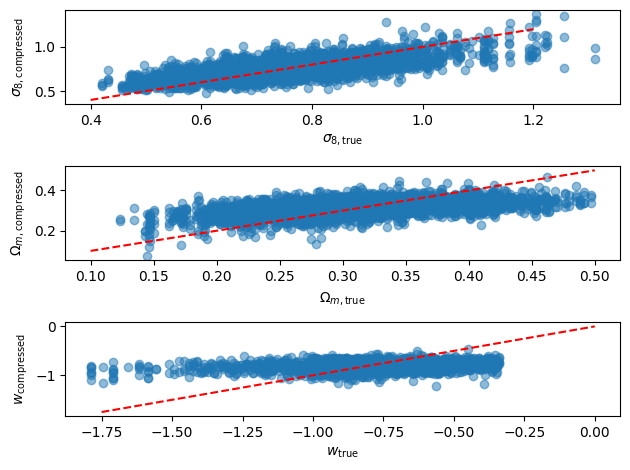

In [28]:
plt.figure()

plt.subplot(311)

plt.scatter(theta_test[:, 1], t_test[:, 1], alpha=0.5)
plt.plot([0.4, 1.2], [0.4, 1.2], linestyle='--', color='red')
plt.xlabel(r'$\sigma_{8, \rm true}$')
plt.ylabel(r'$\sigma_{8, \rm compressed}$')

plt.subplot(312)

plt.scatter(theta_test[:, 0], t_test[:, 0], alpha=0.5)
plt.plot([0.1, 0.5], [0.1, 0.5], linestyle='--', color='red')
plt.xlabel(r'$\Omega_{m, \rm true}$')
plt.ylabel(r'$\Omega_{m, \rm compressed}$')

plt.subplot(313)

plt.scatter(theta_test[:, 2], t_test[:, 2], alpha=0.5)
plt.plot([-1.75, 0.0], [-1.75, 0.0], linestyle='--', color='red')
plt.xlabel(r'$w_{\rm true}$')
plt.ylabel(r'$w_{\rm compressed}$')

plt.tight_layout()

plt.savefig("compression_output.png", dpi=600)
plt.show()

## Perform the inference

In [17]:
def standardize_and_compress(example):
    example = standardize(example)
    example["x"] = MSE_compression_function(example["x"])
    return example

In [18]:
#Not optimal everything is done sequentially
inference_dataset = dataset["inference"].map(standardize_and_compress)

Parameter 'function'=<function standardize_and_compress at 0x14773d105760> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


Map:   0%|          | 0/19750 [00:00<?, ? examples/s]

In [19]:
inference = NPE()

In [20]:
inference = inference.append_simulations_huggingface(inference_dataset)

[!] Inputs are valid.
[!] Appending 19750 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 13824 simulations.
[!] Validation set: 3951 simulations.
[!] Test set: 1975 simulations.


In [21]:
#Let's train the normalizing flow

#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./PS_inference"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 500

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
)

[!] Creating DataLoaders with batch_size 50.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs: Val loss -2.9355/ Best val loss -2.9381:  36%|███▌      | 178/500 [09:05<16:27,  3.07s/it]


Neural network training stopped after 179 epochs.
Early stopping with best validation metric: -2.9380743503570557
Best model saved at epoch 177
Early stopping parameters: min_delta=0.001, patience=20
[!] Training loss: -2.9813520908355713
[!] Validation loss: -2.9389278888702393
[!] Test loss: -2.914124011993408


In [22]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


In [23]:
#We can then evaluate on an element of the test set
sample_test_set = inference._test_dataset[5]

In [24]:
observation, truth = np.array(sample_test_set['x']), np.array(sample_test_set['theta'])
truth = np.concatenate([truth, np.array([truth[1] * np.sqrt(truth[0]/0.3)])])
print("True cosmology:", truth)

True cosmology: [ 0.19432548  0.77814221 -0.55587423  0.62627232]


In [25]:
#Let's sample
num_samples = 10_000
random_key = jax.random.PRNGKey(0)
samples_npe = posterior.sample(
    x=observation, num_samples=num_samples, key=random_key
)

In [26]:
samples_prior = np.column_stack([inference_dataset['Omega_m'], inference_dataset['sigma_8'], inference_dataset['w'], inference_dataset['sigma_8']*np.sqrt(inference_dataset['Omega_m']/0.3)])

Removed no burn in
Removed no burn in


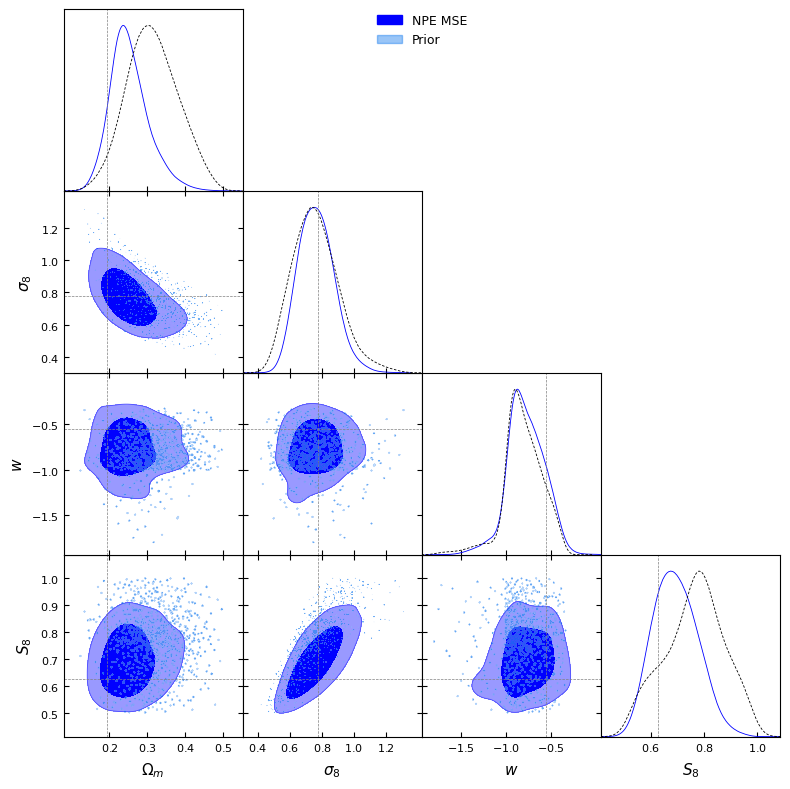

In [27]:
labels = ['\Omega_m', '\sigma_8', 'w', 'S_8']

samples_npe = np.column_stack([samples_npe, samples_npe[:,1]*np.sqrt(samples_npe[:,0]/0.3)])

samples_gd_npe = MCSamples(samples=samples_npe, names=labels, labels=labels)
samples_gd_prior = MCSamples(samples=samples_prior, names=labels, labels=labels)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_npe, samples_gd_prior], filled=True,
                line_args=[
                    {'color': 'blue'},
                    {'color': 'black',
                     'ls': '--'}
                ],
                contour_colors=['blue', None],
                markers={
                    label: val for label, val in zip(labels, truth)
                },
                legend_labels=['NPE MSE', 'Prior'])

plt.savefig("pseudo_cell_constraint_npe.png", dpi=600)
plt.show()

The contours seem to be completely prior dominated. We can try to train a NLE model and see what we get.

In [29]:
inference = NLE()

In [30]:
inference = inference.append_simulations_huggingface(inference_dataset)

[!] Inputs are valid.
[!] Appending 19750 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 13824 simulations.
[!] Validation set: 3951 simulations.
[!] Test set: 1975 simulations.


In [31]:
#Let's train the normalizing flow

#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./PS_inference"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 500

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
)

[!] Creating DataLoaders with batch_size 50.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs: Val loss -4.5216/ Best val loss -4.5255:  13%|█▎        | 65/500 [03:18<22:08,  3.06s/it] 


Neural network training stopped after 66 epochs.
Early stopping with best validation metric: -4.525473594665527
Best model saved at epoch 45
Early stopping parameters: min_delta=0.001, patience=20
[!] Training loss: -4.558619976043701
[!] Validation loss: -4.525473594665527
[!] Test loss: -4.55834436416626


In [45]:
import numpyro.distributions as dist

posterior = inference.build_posterior(
    prior_distr= dist.Uniform(low=jnp.array([0., 0., -1.0]), high=jnp.array([0.6, 1.2, 0.0]))
)

Using MCMC method: nuts_numpyro
MCMC kwargs: {'progress_bar': False}
[!] Posterior $p(\theta| x)$ built. The class MCMCPosterior is used to sample and evaluate the log probability.\n The sampling is performed using MCMC methods.


In [46]:
#Let's sample
num_samples = 10_000
random_key = jax.random.PRNGKey(0)
samples_nle = posterior.sample(
    x=observation.reshape((1, -1)), num_samples=num_samples, key=random_key
)

KeyboardInterrupt: 

Removed no burn in
Removed no burn in
Removed no burn in


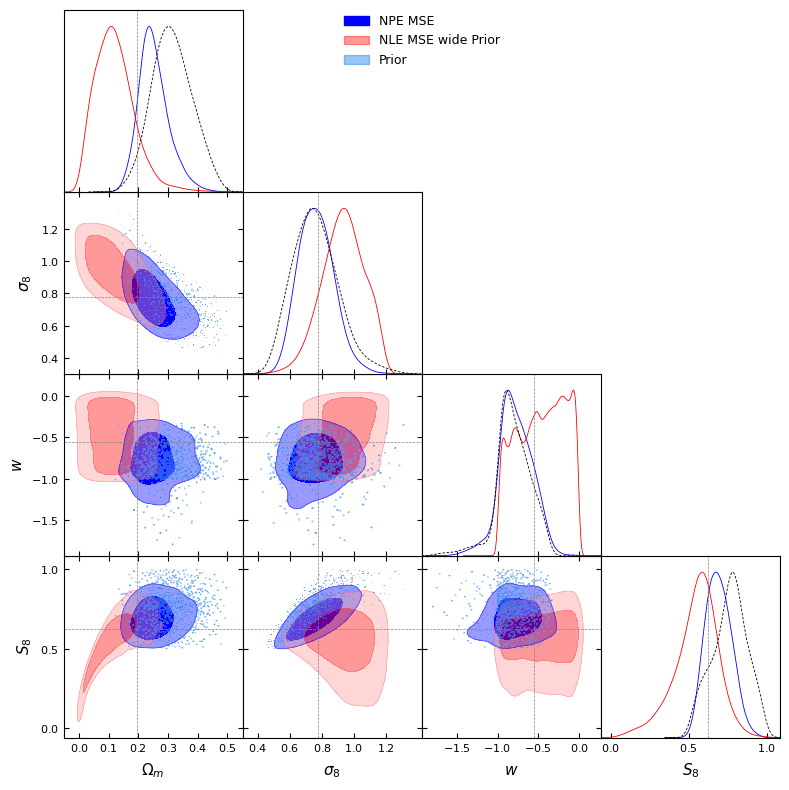

In [40]:
labels = ['\Omega_m', '\sigma_8', 'w', 'S_8']

samples_nle = np.column_stack([samples_nle, samples_nle[:,1]*np.sqrt(samples_nle[:,0]/0.3)])

samples_gd_npe = MCSamples(samples=samples_npe, names=labels, labels=labels)
samples_gd_prior = MCSamples(samples=samples_prior, names=labels, labels=labels)
samples_gd_nle = MCSamples(samples=samples_nle, names=labels, labels=labels)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_npe, samples_gd_nle, samples_gd_prior], filled=True,
                line_args=[
                    {'color': 'blue'},
                    {'color': 'red'},
                    {'color': 'black',
                     'ls': '--'}
                ],
                contour_colors=['blue', 'red', None],
                markers={
                    label: val for label, val in zip(labels, truth)
                },
                legend_labels=['NPE MSE', 'NLE MSE wide Prior', 'Prior'])

plt.savefig("pseudo_cell_constraint_nle.png", dpi=600)
plt.show()

In [47]:
import numpyro.distributions as dist

posterior = inference.build_posterior(
    prior_distr= dist.Uniform(low=jnp.array([0., 0., -0.56]), high=jnp.array([0.6, 1.2, -0.55]))
)

Using MCMC method: nuts_numpyro
MCMC kwargs: {'progress_bar': False, 'num_samples': 10000}
[!] Posterior $p(\theta| x)$ built. The class MCMCPosterior is used to sample and evaluate the log probability.\n The sampling is performed using MCMC methods.


In [48]:
#Let's sample
num_samples = 10_000
random_key = jax.random.PRNGKey(0)
samples_nle_tight_prior = posterior.sample(
    x=observation.reshape((1, -1)), num_samples=num_samples, key=random_key
)

Removed no burn in
Removed no burn in
Removed no burn in


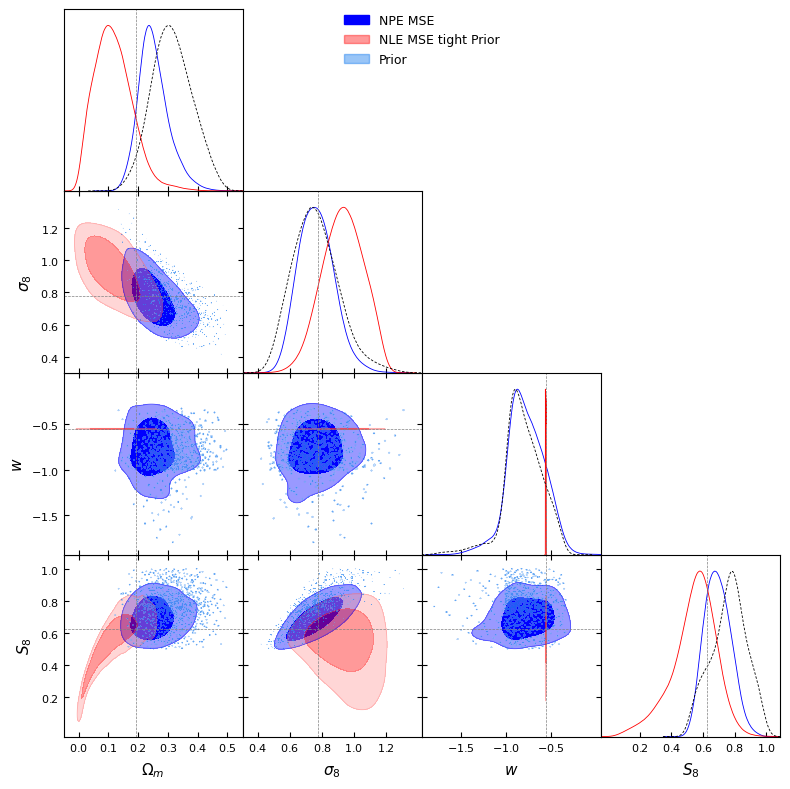

In [49]:
labels = ['\Omega_m', '\sigma_8', 'w', 'S_8']

samples_nle_tight_prior = np.column_stack([samples_nle_tight_prior, samples_nle_tight_prior[:,1]*np.sqrt(samples_nle_tight_prior[:,0]/0.3)])

samples_gd_npe = MCSamples(samples=samples_npe, names=labels, labels=labels)
samples_gd_prior = MCSamples(samples=samples_prior, names=labels, labels=labels)
samples_gd_nle = MCSamples(samples=samples_nle_tight_prior, names=labels, labels=labels)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_npe, samples_gd_nle, samples_gd_prior], filled=True,
                line_args=[
                    {'color': 'blue'},
                    {'color': 'red'},
                    {'color': 'black',
                     'ls': '--'}
                ],
                contour_colors=['blue', 'red', None],
                markers={
                    label: val for label, val in zip(labels, truth)
                },
                legend_labels=['NPE MSE', 'NLE MSE tight Prior', 'Prior'])

plt.savefig("pseudo_cell_constraint_nle_tight_prior.png", dpi=600)
plt.show()

### Learning the likelihood from the pseudo-cell directly?

In [54]:
path_dataset = "/lustre/fswork/projects/rech/prk/commun/GowerStreetSims/UNIONS_sims_pseudo_cell.parquet"

dataset = load_dataset("parquet", data_files=path_dataset)

dataset = dataset.with_format('numpy')

In [55]:
def dataset_preprocessing(example):
    example['theta'] = np.array([example["Omega_m"], example["sigma_8"], example["w"]])
    pseudo_cell = example["pseudo_cell"].reshape((4, -1))
    example['x'] = np.concatenate([pseudo_cell[0], pseudo_cell[3]]).flatten()
    return example

In [56]:
dataset = dataset.map(dataset_preprocessing)

Map:   0%|          | 0/39500 [00:00<?, ? examples/s]

In [57]:
inference = NLE()

In [60]:
inference = inference.append_simulations_huggingface(dataset["train"])

[!] Inputs are valid.
[!] Appending 39500 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 27649 simulations.
[!] Validation set: 7901 simulations.
[!] Test set: 3950 simulations.


In [61]:
#Let's train the normalizing flow

#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./PS_inference"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 500

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
)

[!] Creating DataLoaders with batch_size 50.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs: Val loss -1186.8/ Best val loss -1186.9:   8%|▊         | 42/500 [04:16<46:31,  6.10s/it] 


Neural network training stopped after 43 epochs.
Early stopping with best validation metric: -1186.8853759765625
Best model saved at epoch 22
Early stopping parameters: min_delta=0.001, patience=20
[!] Training loss: -1187.123046875
[!] Validation loss: -1186.8853759765625
[!] Test loss: -1186.711669921875


In [72]:
import numpyro.distributions as dist

posterior = inference.build_posterior(
    prior_distr= dist.Uniform(low=jnp.array([0., 0., -0.81]), high=jnp.array([0.6, 1.2, -0.80]))
)

Using MCMC method: nuts_numpyro
MCMC kwargs: {'progress_bar': False}
[!] Posterior $p(\theta| x)$ built. The class MCMCPosterior is used to sample and evaluate the log probability.\n The sampling is performed using MCMC methods.


In [63]:
#We can then evaluate on an element of the test set
sample_test_set = inference._test_dataset[5]

In [64]:
observation, truth = np.array(sample_test_set['x']), np.array(sample_test_set['theta'])
truth = np.concatenate([truth, np.array([truth[1] * np.sqrt(truth[0]/0.3)])])
print("True cosmology:", truth)

True cosmology: [ 0.3742114   0.85369724 -0.80199933  0.95345842]


In [73]:
#Let's sample
num_samples = 10_000
random_key = jax.random.PRNGKey(0)
samples_nle_full_cell = posterior.sample(
    x=observation.reshape((1, -1)), num_samples=num_samples, key=random_key
)
samples_nle_full_cell = np.column_stack([samples_nle_full_cell, samples_nle_full_cell[:,1]*np.sqrt(samples_nle_full_cell[:,0]/0.3)])

Removed no burn in
Removed no burn in


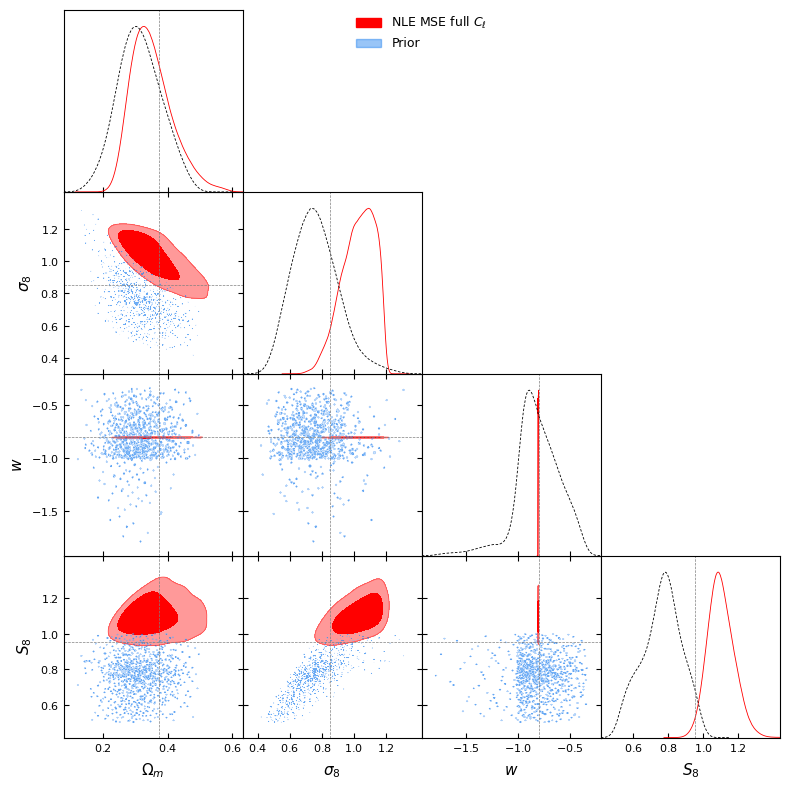

In [74]:
labels = ['\Omega_m', '\sigma_8', 'w', 'S_8']

samples_gd_prior = MCSamples(samples=samples_prior, names=labels, labels=labels)
samples_gd_nle_full_cell = MCSamples(samples=samples_nle_full_cell, names=labels, labels=labels)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_nle_full_cell, samples_gd_prior], filled=True,
                line_args=[
                    {'color': 'red'},
                    {'color': 'black',
                     'ls': '--'}
                ],
                contour_colors=['red', None],
                markers={
                    label: val for label, val in zip(labels, truth)
                },
                legend_labels=[r'NLE MSE full $C_{\ell}$', 'Prior'])

plt.savefig("pseudo_cell_constraint_nle_full_cell.png", dpi=600)
plt.show()